In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import warnings
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder, StandardScaler, OneHotEncoder,PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('StudentPerformanceFactors.csv')

In [4]:
df.sample(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1789,28,89,Medium,Low,Yes,6,71,Low,Yes,2,Low,Medium,Private,Neutral,4,No,College,Moderate,Male,70
1208,12,70,Medium,High,No,5,53,Medium,Yes,2,Low,Medium,Private,Positive,3,No,College,Near,Male,63
1793,24,75,Medium,Low,No,9,95,High,Yes,0,Medium,High,Public,Positive,2,No,College,Near,Male,68
2557,20,97,Medium,High,Yes,5,63,Medium,Yes,0,Low,NaN,Public,Negative,3,No,College,Far,Female,69
2363,27,86,Medium,Medium,Yes,8,79,Medium,Yes,2,Low,High,Private,Positive,4,No,College,Near,Male,72


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [7]:
df=df[df['Exam_Score']<=100]

In [8]:
df.duplicated().sum()

0

In [9]:
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [10]:
## Missing values based on column prior to its percentage
missing_percentage=df.isna().mean()*100
missing_percentage

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.180745
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.362398
Distance_from_Home            1.014229
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64

In [11]:
## Train_Test_Split before doing EDA to avoid any data leakage
X=df.drop('Exam_Score', axis=1)
y=df['Exam_Score']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.75,random_state=42)

## EDA

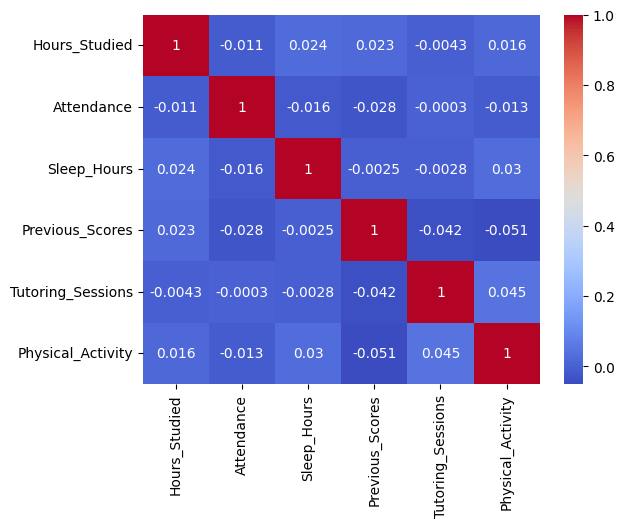

In [12]:
## Heatmap to see how features are correlated with each other(To avoid multi-collinearity)
sns.heatmap(X_train.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

## Insights on Heatmap
- No sign of Multi-Collinearity

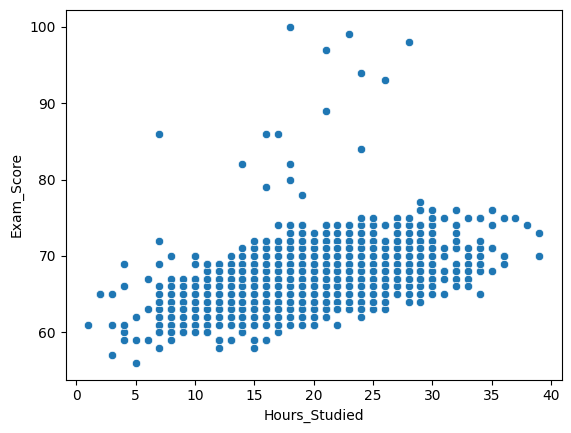

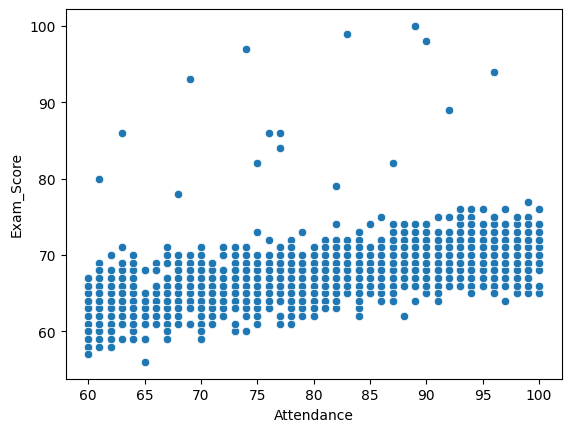

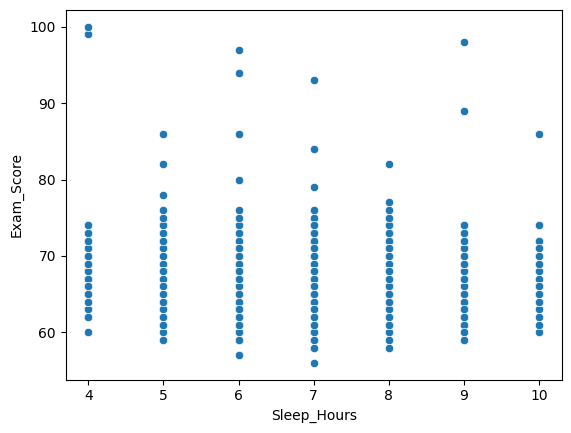

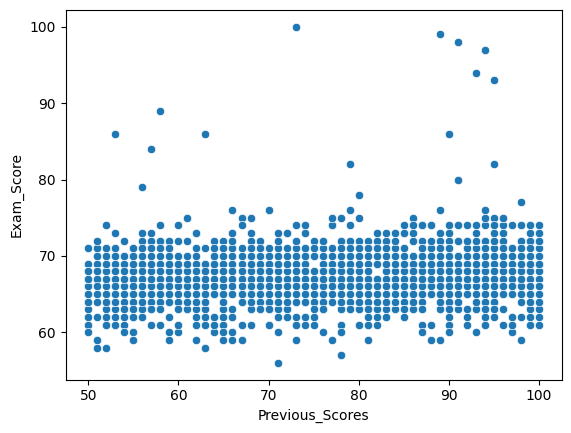

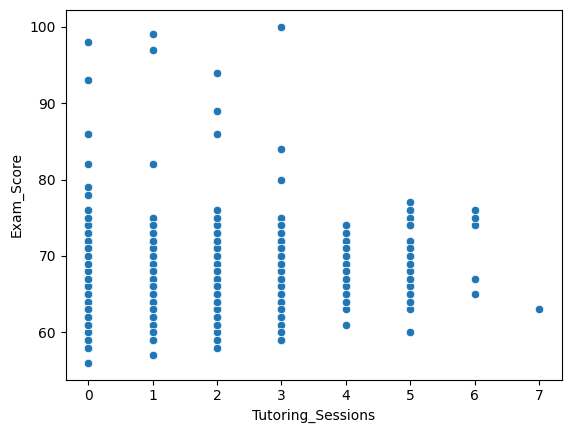

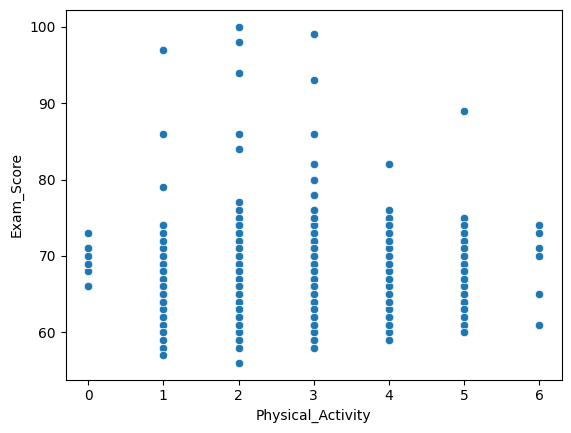

In [13]:
## Scatter plot between X_train and Y_train to see any linearity between them
numeric_cols=X_train.select_dtypes(include=np.number).columns

for i in numeric_cols:
    sns.scatterplot(x=X_train[i],y=y_train)
    plt.show()

## Insights on Scatter Plot
- For best industry practice i used X_train and Y_train instead of the whole df
- Theres barely any linear relationship between feature columns and target columns as of now

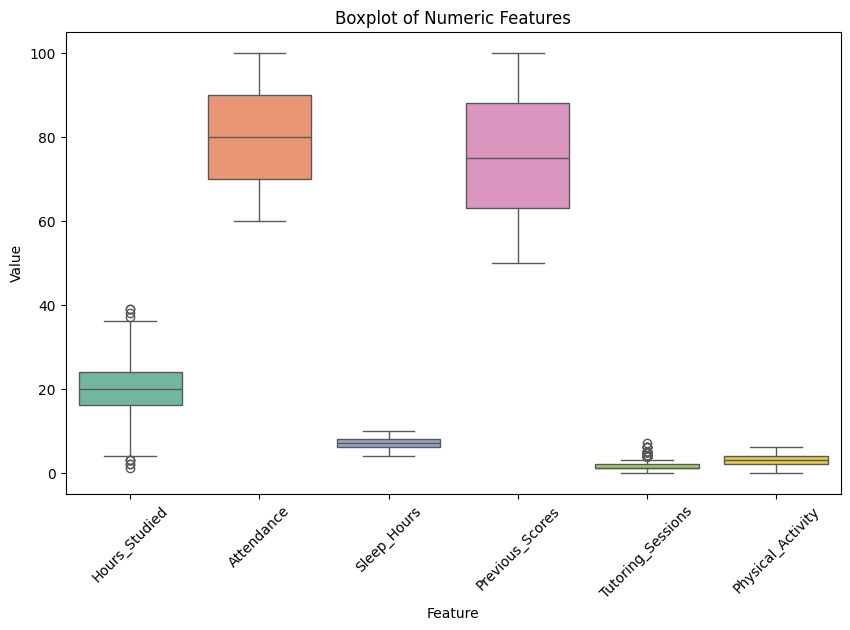

In [14]:
## Box-Plot
df_melt = X_train[numeric_cols].melt(var_name="Feature", value_name="Value")

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Feature", y="Value", data=df_melt, palette="Set2")
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)  # rotate labels if too long
plt.show()

## Insights on Box-Plot
- Hours_Studied and Tutoring Session has some outliers
- Hours_Studied->In an average, many students studies for around 19-20 hr while some talented students can study up to 40+hr a week
- Tutoring_Sessions->Lowers Grade students will have less tutoring session while the talented ones may have high Tutoring session

Final Conclusion-->Either we can drop these outliers or cap them but based on my intution they are useful data and not really some grabage outliers so we keep them for now.

## More EDA

In [15]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


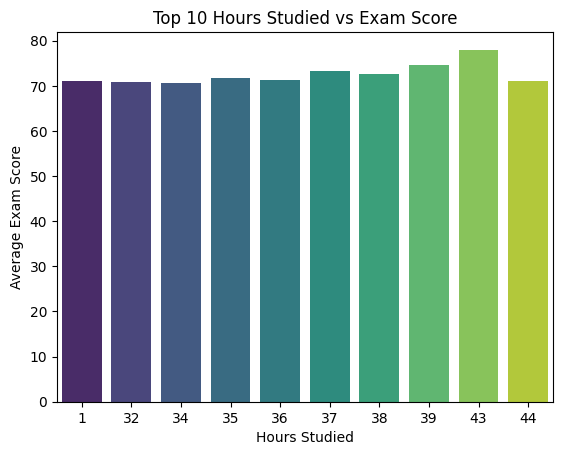

In [16]:
# Bar plot on Hours Studied vs Exam Score 
top10=df.groupby(['Hours_Studied'])['Exam_Score'].mean().nlargest(10)
top10_df=top10.reset_index().sort_values(by='Hours_Studied',ascending=False)

sns.barplot(x='Hours_Studied',y='Exam_Score',data=top10_df,palette='viridis')
plt.title('Top 10 Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Average Exam Score')
plt.show()

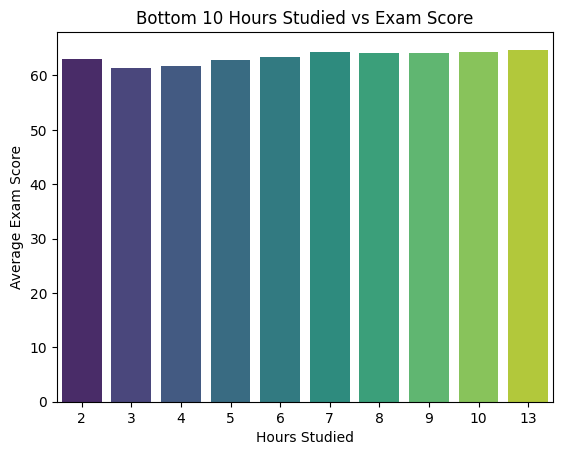

In [17]:
# Bar plot on Hours Studied vs Exam Score 
bottom10=df.groupby(['Hours_Studied'])['Exam_Score'].mean().nsmallest(10)
bottom10_df=bottom10.reset_index()

sns.barplot(x='Hours_Studied',y='Exam_Score',data=bottom10_df,palette='viridis')
plt.title('Bottom 10 Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Average Exam Score')
plt.show()

## Insights on Hours Studied vs Marks Scored
- We can clearly see the more you study, the more marks you obtain
- I guess theres really people that can obtain outstanding marks while only studying for only an hour

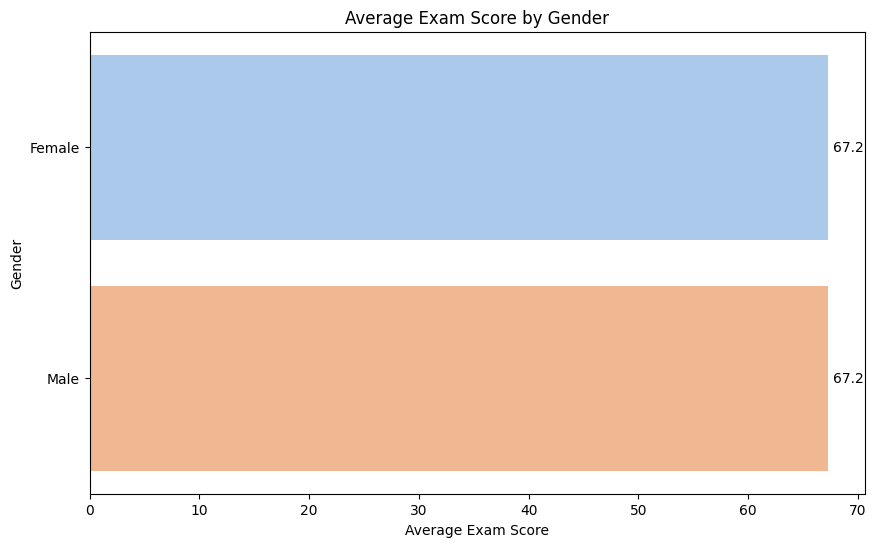

In [18]:
## Gender vs Marks Scored
mf=df.groupby(['Gender'])['Exam_Score'].mean()
mf_df = mf.reset_index() 


plt.figure(figsize=(10,6))
sns.barplot(x='Exam_Score', y='Gender', data=mf_df, palette='pastel')

# Add values on top of bars
for index, row in mf_df.iterrows():
    plt.text(x=row['Exam_Score'] + 0.5, y=index, s=f"{row['Exam_Score']:.1f}", va='center')

plt.xlabel('Average Exam Score')
plt.ylabel('Gender')
plt.title('Average Exam Score by Gender')
plt.show()

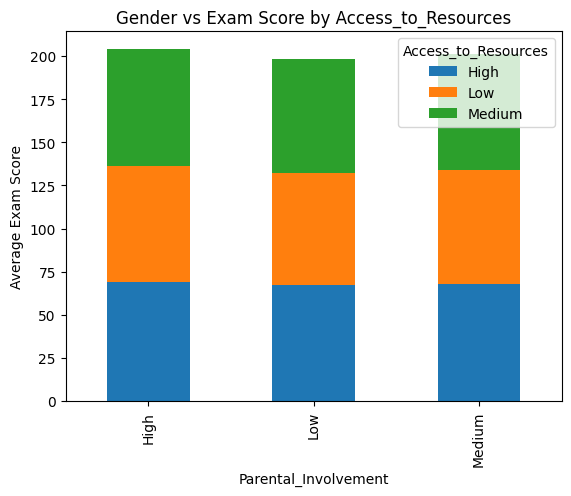

In [19]:
agg = df.groupby(['Parental_Involvement', 'Access_to_Resources'])['Exam_Score'].mean().unstack()
agg.plot(kind='bar', stacked=True)
plt.ylabel('Average Exam Score')
plt.title('Gender vs Exam Score by Access_to_Resources')
plt.show()


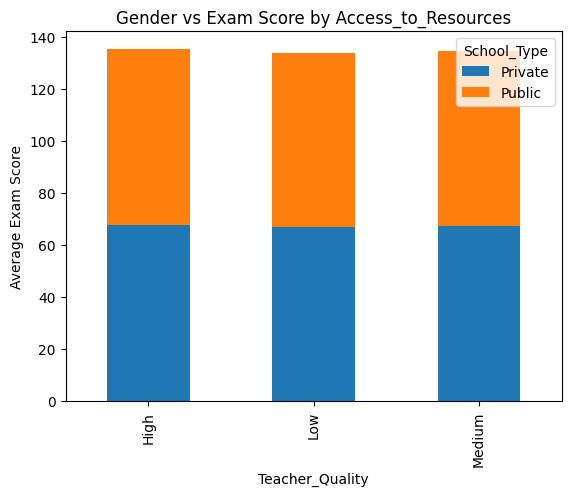

In [20]:
agg = df.groupby(['Teacher_Quality', 'School_Type'])['Exam_Score'].mean().unstack()
agg.plot(kind='bar', stacked=True)
plt.ylabel('Average Exam Score')
plt.title('Gender vs Exam Score by Access_to_Resources')
plt.show()


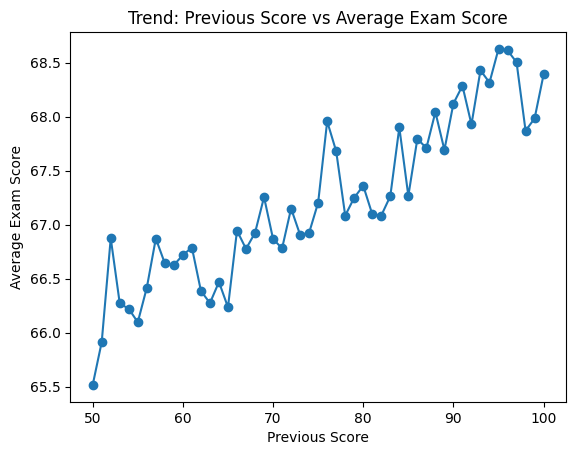

In [21]:
avg_scores = df.groupby('Previous_Scores')['Exam_Score'].mean()
avg_scores.plot(kind='line', marker='o')
plt.xlabel('Previous Score')
plt.ylabel('Average Exam Score')
plt.title('Trend: Previous Score vs Average Exam Score')
plt.show()


## Model Development

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6606 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6606 non-null   int64 
 1   Attendance                  6606 non-null   int64 
 2   Parental_Involvement        6606 non-null   object
 3   Access_to_Resources         6606 non-null   object
 4   Extracurricular_Activities  6606 non-null   object
 5   Sleep_Hours                 6606 non-null   int64 
 6   Previous_Scores             6606 non-null   int64 
 7   Motivation_Level            6606 non-null   object
 8   Internet_Access             6606 non-null   object
 9   Tutoring_Sessions           6606 non-null   int64 
 10  Family_Income               6606 non-null   object
 11  Teacher_Quality             6528 non-null   object
 12  School_Type                 6606 non-null   object
 13  Peer_Influence              6606 non-null   object
 1

In [23]:
## Preprocessing stuffs such as encoding,scaling,imputing etc
exclude = ['Extracurricular_Activities','Internet_Access','School_Type','Peer_Influence','Distance_from_Home','Gender','Learning_Disabilities']
oe = [col for col in df.select_dtypes(include='object').columns if col not in exclude][0:5]
oe2=['Parental_Education_Level']
le=exclude

le_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  
])

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder(categories=[['Low','Medium','High']] * len(oe)))
])

cat_pipeline2 = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder(categories=[['High School','College','Postgraduate']]))
])

In [24]:
## final preprocessing(intergation of above preprocessors)
preprocessing = ColumnTransformer(
    transformers=[
        ('cat1', cat_pipeline, oe),        
        ('cat2', cat_pipeline2, oe2),     
        ('le', le_pipeline, le),           
        ('scaler', StandardScaler(), numeric_cols) 
    ],
    remainder='passthrough'
)


In [25]:
## LinearRegression
pipe_lr=Pipeline([
    ('preprocessing',preprocessing),
    ('model',LinearRegression())
])

## Linear Regression

In [26]:
pipe_lr.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat1', ...), ('cat2', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
y_pred_lr=pipe_lr.predict(X_test)

In [28]:
pipe_pr=Pipeline([
    ('preprocessing',preprocessing),
    ('model2',PolynomialFeatures(degree=4)),
    ('model',LinearRegression())
])

In [33]:
## Error Metrics for Linear Regression
mae=mean_absolute_error(y_test,y_pred_lr)
mse=mean_squared_error(y_test,y_pred_lr)
rmse=np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2  = r2_score(y_test, y_pred_lr)

print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R2:', r2)

MAE: 0.5113292056852665
MSE: 3.811016091273068
RMSE: 1.9521823919073413
R2: 0.7406706510390407


## Insights on Error metric for Linear Regression
- RMSE is in the same units as target, so on average our predictions are 1.85 points away from the true score.
- Model is performing exceptionally well since on avg our target columns ranges from 40-100 units and error margin of 1.85 unit is really really well
- It is able to explain almost 75% variability of the target which is pretty good considering the ration between higher score and mid score is imbalanced.

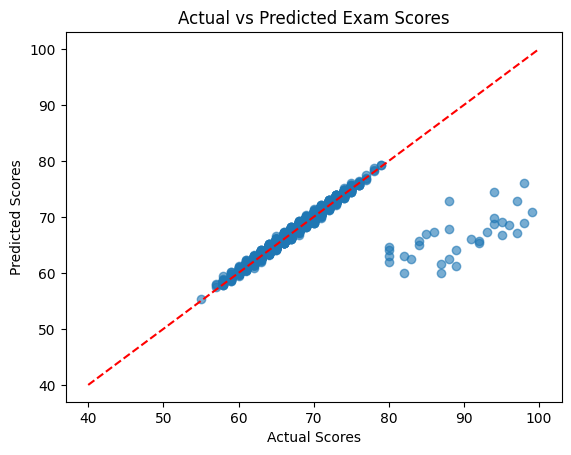

In [34]:
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([40, 100], [40, 100], color='red', linestyle='--')  # perfect prediction line
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Exam Scores")
plt.show()

## Insights on Actual vs Predicted Scores
- Our model is really performing well for the marks ranging from 55-80 but is doing bad for the marks ranging from 80-100.
- This is because most of the values on our target column ranges from 50-80 and theres only few high scores(80-100) and we know that
    linear regression tends to pull prediction toward the mean

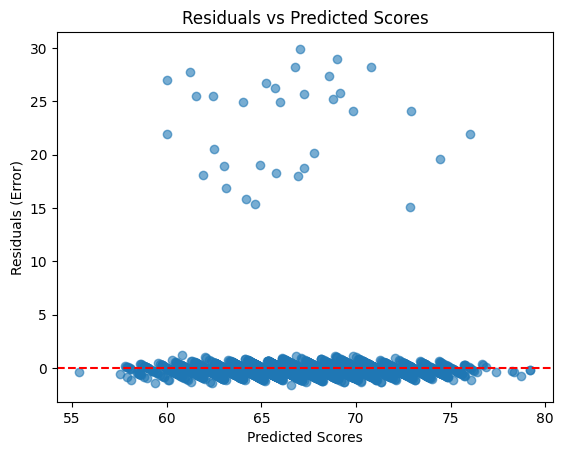

In [35]:
residuals_lr = y_test - y_pred_lr
plt.scatter(y_pred_lr, residuals_lr, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Scores")
plt.ylabel("Residuals (Error)")
plt.title("Residuals vs Predicted Scores")
plt.show()

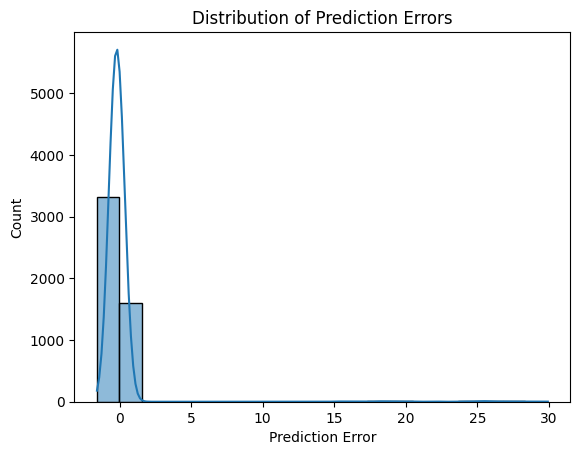

In [36]:
sns.histplot(residuals_lr, kde=True, bins=20)
plt.xlabel("Prediction Error")
plt.title("Distribution of Prediction Errors")
plt.show()


## Polynomial Regression

In [37]:
pipe_pr.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('model2', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat1', ...), ('cat2', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
y_pred_pr=pipe_pr.predict(X_test)

In [39]:
mae=mean_absolute_error(y_test,y_pred_lr)
mse=mean_squared_error(y_test,y_pred_lr)
rmse=np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2  = r2_score(y_test, y_pred_pr)

print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R2:', r2)

MAE: 0.5113292056852665
MSE: 3.811016091273068
RMSE: 1.9521823919073413
R2: 0.20974946726081511


In [ ]:
plt.scatter(y_test, y_pred_pr, alpha=0.6)
plt.plot([40, 100], [40, 100], color='red', linestyle='--')  # perfect prediction line
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Exam Scores")
plt.show()

In [ ]:
residuals_pr = y_test - y_pred_pr
plt.scatter(y_pred_pr, residuals_pr, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Scores")
plt.ylabel("Residuals (Error)")
plt.title("Residuals vs Predicted Scores")
plt.show()


In [ ]:
sns.histplot(residuals_pr, kde=True, bins=20)
plt.xlabel("Prediction Error")
plt.title("Distribution of Prediction Errors")
plt.show()


## FINAL CONCLUSIONS:
- Linear Regression model is perfroming exceptionally well for the mid range exam scores and bad for the high score ones due to the imbalance
    in the range of values itself.
- Polynomial Regression is performing a bit better for the high scores but again with the cost of performing bad on the mid ones and hence it is only
  able to explain 20% of the varaince of the target variable
                                                                                                